
Feature selection is a crucial step in machine learning that helps improve model performance, reduce overfitting, and speed up training time by selecting the most relevant features from the dataset.

There are three main types of feature selection methods:

* Filter Methods (Based on statistical measures)
* Wrapper Methods (Based on model performance)
* Embedded Methods (Feature selection integrated within the model)

Why feature selection?

* Removes irrelevant or redundant features
* Reduces computational complexity
* Helps avoid the curse of dimensionality
* Improves model interpretability
* Enhances generalization by reducing overfitting

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Filter Methods (Statistical approaches)

Filter methods evaluate the relevance of features based on statistical measures before training a model. These methods rank features according to their correlation with the target variable and select the most relevant ones.

### **Characteristics:**
- **Independent of the model:** Feature selection is performed before training the model.
- **Fast and computationally efficient:** Since no model training is required, they are suitable for large datasets.
- **Prone to selecting irrelevant features:** They do not consider interactions between features.
- **Common techniques:**
  - Pearson correlation coefficient
  - Mutual information
  - Chi-square test
  - ANOVA (Analysis of Variance)
  - Variance thresholding

In [15]:
#| echo: false

# import image module
from IPython.display import Image

# get the image
Image(url="./Datasets/filter_methods.png",width=700, height=300)

### Methods

| Method               | Description                                         | Python Function/Class              | Notes |
|----------------------|-----------------------------------------------------|------------------------------------|-------------------------------------------------|
| **Variance Threshold** | Removes low-variance numeric features              | `VarianceThreshold()` (scikit-learn) | Only works on numerical features |
| **Correlation Filter** | Removes highly correlated features                 | Custom implementation + `df.corr()` | Requires manual analysis (pandas) or `correlation_threshold` methods |
| **Chi-Square Test**   | Selects categorical features for classification     | `chi2()` + `SelectKBest()`        | For categorical targets, requires non-negative features |
| **Mutual Information** | Measures dependency for classification/regression  | `mutual_info_classif()`/`regression()` | Used with `SelectKBest()` or `SelectPercentile()` |


In [2]:

from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression

# Load the data
df = pd.read_csv('./Datasets/Credit.csv', index_col=0)

# Separate features and target
# Let's use 'Balance' as our target variable
X = df.drop('Balance', axis=1)
y = df['Balance']

# Preprocessing: Encode categorical variables
X_encoded = pd.get_dummies(X, columns=['Gender', 'Student', 'Married', 'Ethnicity'])

# 1. Variance Threshold Feature Selection
def variance_threshold_selection(X, threshold=0.1):
    # Create a VarianceThreshold selector
    selector = VarianceThreshold(threshold=threshold)
    
    # Fit and transform the data
    X_selected = selector.fit_transform(X)
    
    # Get the selected feature names
    selected_features = X.columns[selector.get_support()]
    
    return X_selected, selected_features

# Apply Variance Threshold
X_var_selected, var_selected_features = variance_threshold_selection(X_encoded)

print("1. Variance Threshold Feature Selection:")
print("Selected features:", list(var_selected_features))
print("Number of features reduced from", X_encoded.shape[1], "to", len(var_selected_features))


1. Variance Threshold Feature Selection:
Selected features: ['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 'Gender_ Male', 'Gender_Female', 'Married_No', 'Married_Yes', 'Ethnicity_African American', 'Ethnicity_Asian', 'Ethnicity_Caucasian']
Number of features reduced from 15 to 13


**Interpretation:**

- **Variance Threshold** removes features with low variability (i.e., features that don't change much). In this dataset, categorical features encoded as binary (0/1) may have low variance if the distribution is heavily skewed.
- Features with very low variance typically don't contribute much information for prediction, so removing them helps reduce dimensionality without losing predictive power.
- This method is fast and simple but doesn't consider the relationship with the target variable.


3. Correlation-based Feature Removal:
Dropped features: ['Rating', 'Gender_Female', 'Student_Yes', 'Married_Yes']
Number of features reduced from 15 to 11


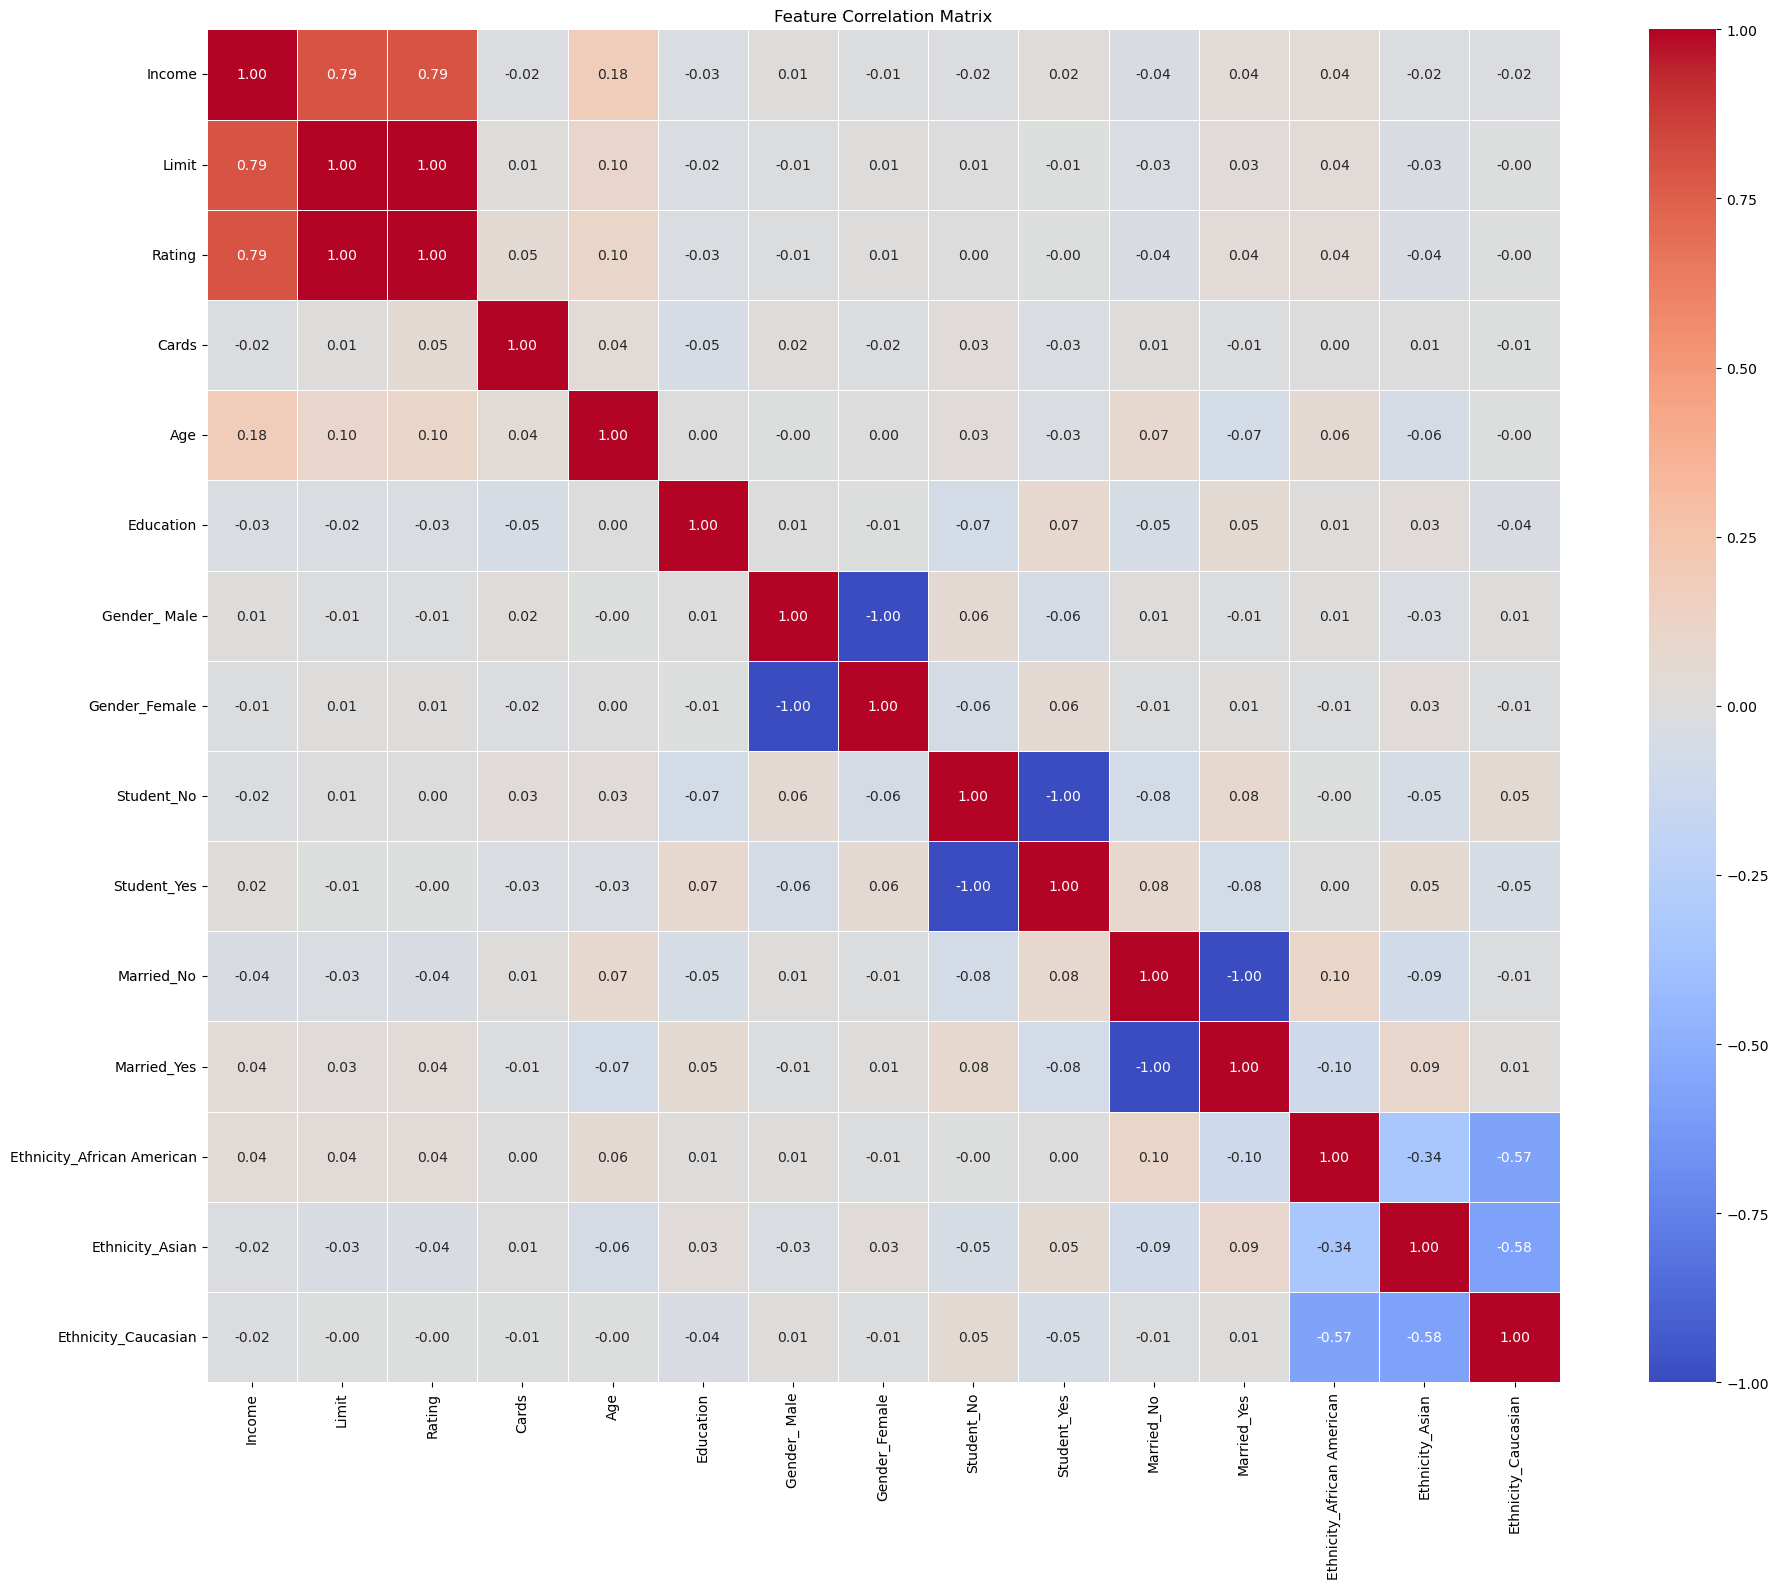

In [3]:
# 2. Correlation-based Feature Removal
def remove_highly_correlated_features(X, threshold=0.8):
    # Compute the correlation matrix
    corr_matrix = X.corr().abs()
    
    # Create a mask of the upper triangle of the correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Find features to drop
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Drop highly correlated features
    X_reduced = X.drop(columns=to_drop)
    
    return X_reduced, to_drop

# Apply Correlation-based Feature Removal
X_corr_removed, dropped_features = remove_highly_correlated_features(X_encoded)

print("\n3. Correlation-based Feature Removal:")
print("Dropped features:", dropped_features)
print("Number of features reduced from", X_encoded.shape[1], "to", X_corr_removed.shape[1])

# Visualization of Correlation Matrix
plt.figure(figsize=(20,16))
correlation_matrix = X_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f", square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout();

In [4]:
# 3. Correlation-based Feature Selection (with target)
def correlation_with_target_selection(X, y, threshold=0.2):
    # Calculate correlation with target
    correlations = X.apply(lambda col: col.corr(y))
    
    # Select features above the absolute correlation threshold
    selected_features = correlations[abs(correlations) >= threshold].index
    
    return X[selected_features], selected_features

# Apply Correlation with Target Selection
X_corr_target, corr_target_features = correlation_with_target_selection(X_encoded, y)

print("\n2. Correlation with Target Feature Selection:")
print("Selected features:", list(corr_target_features))
print("Number of features reduced from", X_encoded.shape[1], "to", len(corr_target_features))


2. Correlation with Target Feature Selection:
Selected features: ['Income', 'Limit', 'Rating', 'Student_No', 'Student_Yes']
Number of features reduced from 15 to 5


**Interpretation:**

- **Correlation with Target** identifies features that have a strong linear relationship with the outcome variable (Balance).
- Features like `Rating`, `Limit`, and `Income` likely show strong positive correlations because they logically relate to credit balance.
- This method is effective for linear models but may miss non-linear relationships.
- The threshold of 0.2 is arbitrary - you may want to experiment with different values based on your domain knowledge.

Correlations with Balance (sorted by absolute value):
Rating: 0.863625160621495
Limit: 0.8616972670153951
Income: 0.46365645701575736
Student_No: 0.2590175474501476
Student_Yes: 0.2590175474501476
Cards: 0.08645634741861911
Gender_ Male: 0.021474006717338588
Gender_Female: 0.021474006717338588
Ethnicity_African American: 0.013719801718047214
Ethnicity_Asian: 0.00981223592782398
Education: 0.00806157645355343
Married_Yes: 0.005673490217239985
Married_No: 0.005673490217239973
Ethnicity_Caucasian: 0.003288321172097514
Age: 0.0018351188590736563


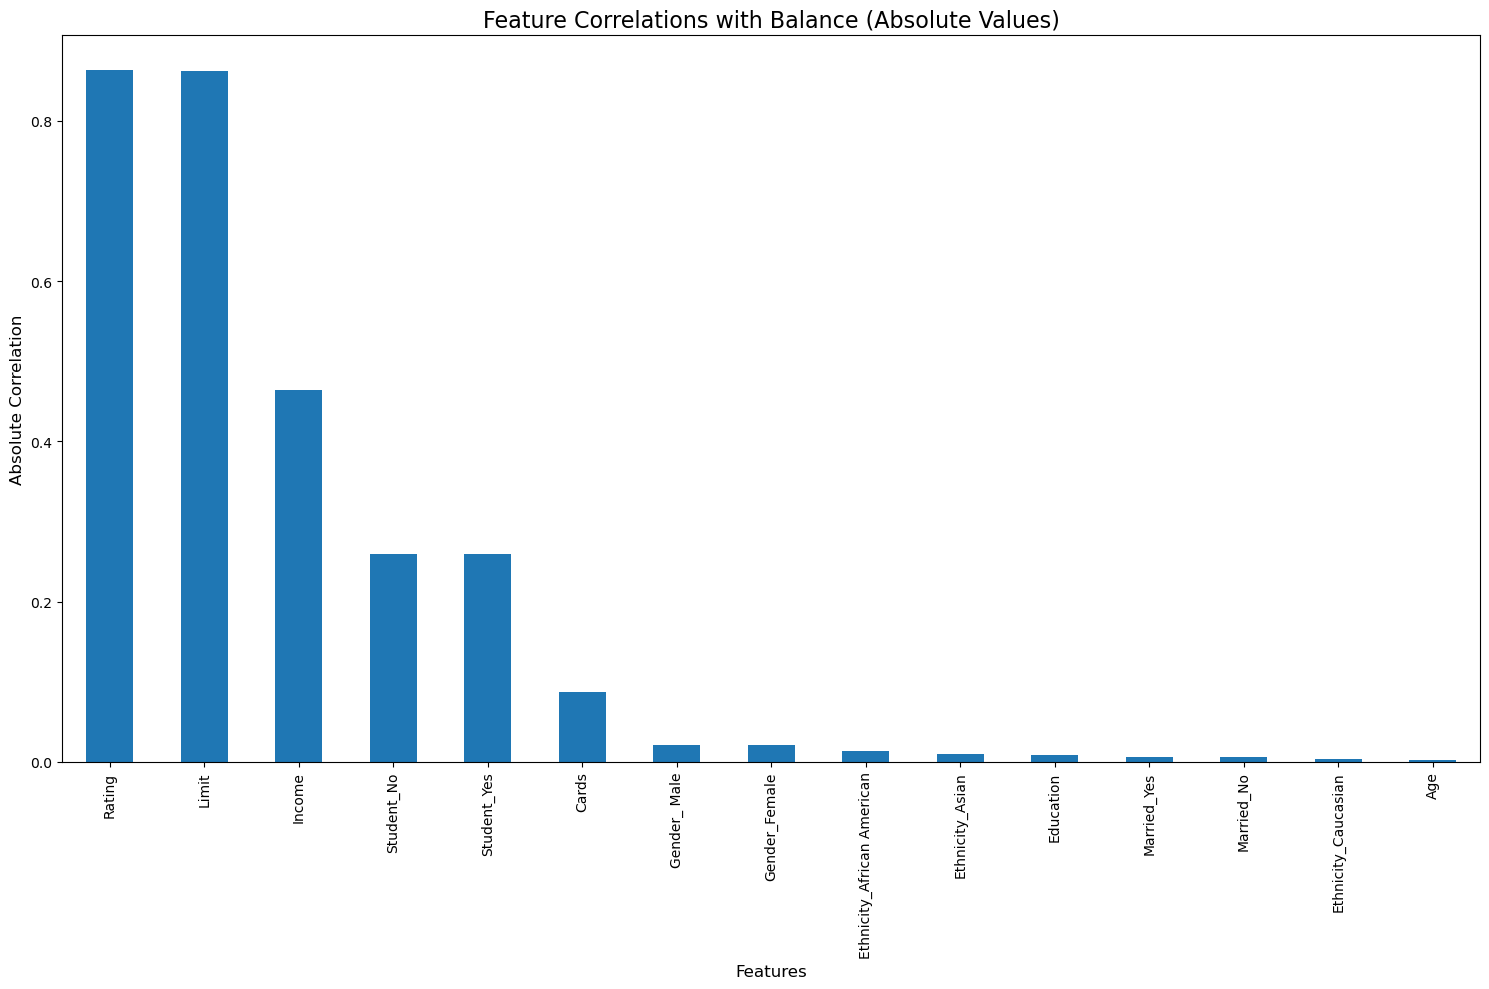

In [5]:
# Calculate correlations with target
correlations = X_encoded.apply(lambda col: col.corr(y))

# Sort correlations by absolute value in descending order
correlations_sorted = correlations.abs().sort_values(ascending=False)

# Prepare the visualization
plt.figure(figsize=(15, 10))
correlations_sorted.plot(kind='bar')
plt.title('Feature Correlations with Balance (Absolute Values)', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Absolute Correlation', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Print out the sorted correlations
print("Correlations with Balance (sorted by absolute value):")
for feature, corr in correlations_sorted.items():
    print(f"{feature}: {corr}")

In [6]:
# 4. SelectKBest Feature Selection
def select_k_best_features(X, y, k=5):
    # Create a SelectKBest selector
    selector = SelectKBest(score_func=f_regression, k=k)
    
    # Fit and transform the data
    X_selected = selector.fit_transform(X, y)
    
    # Get the selected feature names
    selected_features = X.columns[selector.get_support()]
    
    return X_selected, selected_features

# Apply SelectKBest
X_k_best, k_best_features = select_k_best_features(X_encoded, y)

print("\n4. SelectKBest Feature Selection:")
print("Selected features:", list(k_best_features))
print("Number of features reduced from", X_encoded.shape[1], "to", len(k_best_features))


4. SelectKBest Feature Selection:
Selected features: ['Income', 'Limit', 'Rating', 'Student_No', 'Student_Yes']
Number of features reduced from 15 to 5


##  Wrapper Methods

Wrapper methods evaluate subsets of features by actually training and testing a model on different feature combinations. These methods optimize feature selection based on model performance.

### Characteristics:
- **Model-dependent:** They rely on training a model to assess feature usefulness.
- **Computationally expensive:** Since multiple models need to be trained, they can be slow, especially for large datasets.
- **More accurate than filter methods:** They account for feature interactions and can find the optimal subset.
- **Risk of overfitting:** Since they optimize for a specific dataset, the selected features may not generalize well to new data.
- **Common techniques:**
  - Recursive Feature Elimination (RFE)
  - Sequential Feature Selection (SFS) (Forward/Backward Selection)

  
- Wrapper methods can be explained with the help of following graphic:

In [29]:
#| echo: false

# import image module
from IPython.display import Image

# get the image
Image(url="./Datasets/wrapper.webp",width=800, height=200)

### Recursive Feature Elimination (RFE)

This is how RFE works:

* Start with all features in the dataset.
* Train a model (e.g., Random Forest, SVM, Logistic Regression).
* Rank feature importance using model coefficients (`coef_`) or feature importance scores (`feature_importances_`).
* Remove the least important feature(s).
* Repeat steps 2-4 recursively until reaching the desired number of features.
* Return the best subset of features.

In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier


# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Initialize a model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Apply Recursive Feature Elimination (RFE)
rfe_selector = RFE(model, n_features_to_select=5)  # Select top 5 features
X_rfe_selected = rfe_selector.fit_transform(X, y)

# Get selected feature names
rfe_selected_features = X.columns[rfe_selector.support_]
print("Selected features using RFE:", rfe_selected_features.tolist())


Selected features using RFE: ['mean concave points', 'worst radius', 'worst perimeter', 'worst area', 'worst concave points']


### Recursive Feature Elimination with Cross-Validation (RFECV)

RFECV is an extension of Recursive Feature Elimination (RFE) that automatically selects the optimal number of features using cross-validation.

In [8]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Initialize model (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5)

# Apply RFECV
rfecv_selector = RFECV(estimator=model, step=1, cv=cv, scoring='accuracy', n_jobs=-1)
X_rfecv_selected = rfecv_selector.fit_transform(X, y)

# Get selected feature names
rfecv_selected_features = X.columns[rfecv_selector.support_]
print("Optimal number of features:", rfecv_selector.n_features_)
print("Selected features using RFECV:", rfecv_selected_features.tolist())

# Print feature rankings
feature_ranking = pd.DataFrame({'Feature': X.columns, 'Ranking': rfecv_selector.ranking_})
print(feature_ranking.sort_values(by='Ranking'))


Optimal number of features: 16
Selected features using RFECV: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points', 'radius error', 'area error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points']
                    Feature  Ranking
0               mean radius        1
22          worst perimeter        1
23               worst area        1
13               area error        1
24         worst smoothness        1
25        worst compactness        1
10             radius error        1
21            worst texture        1
26          worst concavity        1
7       mean concave points        1
6            mean concavity        1
3                 mean area        1
2            mean perimeter        1
1              mean texture        1
27     worst concave points        1
20             worst radius        1
28           worst symmet

### Sequential Feature Selection

SFS iteratively selects the most relevant features by **adding them one at a time (forward selection)** or **removing them one at a time (backward elimination)** while evaluating model performance at each step. 

The selection strategy is controlled using:

- `direction='forward'` for **feature addition**
- `direction='backward'` for **feature removal**


In [9]:
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.linear_model import LogisticRegression

# Initialize a model
model = LogisticRegression(max_iter=1000)

# Apply Sequential Feature Selection (SFS)
sfs_selector = SequentialFeatureSelector(model, n_features_to_select=5, direction='forward', n_jobs=-1)
X_sfs_selected = sfs_selector.fit_transform(X, y)

# Get selected feature names
sfs_selected_features = X.columns[sfs_selector.get_support()]
print("Selected features using SFS:", sfs_selected_features.tolist())


Selected features using SFS: ['mean radius', 'radius error', 'worst texture', 'worst perimeter', 'worst compactness']


Let's use them on the *credit* dataset

In [10]:

# Load the data
df = pd.read_csv('./Datasets/Credit.csv', index_col=0)

# Separate features and target
X = df.drop('Balance', axis=1)
y = df['Balance']

# Preprocessing
# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=['Gender', 'Student', 'Married', 'Ethnicity'])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Recursive Feature Elimination with Cross-Validation (RFECV)
def perform_rfecv(X_train, y_train, X_test, y_test):
    # Use both Linear Regression and Random Forest
    estimators = [
        ('Linear Regression', LinearRegression()),
        ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42))
    ]
    
    results = {}
    
    for name, estimator in estimators:
        # RFECV with cross-validation
        rfecv = RFECV(
            estimator=estimator, 
            step=1, 
            cv=5, 
            scoring='neg_mean_squared_error'
        )
        
        # Fit RFECV
        rfecv.fit(X_train, y_train)
        
        # Get selected features
        selected_features = X_train.columns[rfecv.support_]
        
        # Prepare reduced datasets
        X_train_reduced = X_train[selected_features]
        X_test_reduced = X_test[selected_features]
        
        # Fit the model on reduced dataset
        estimator.fit(X_train_reduced, y_train)
        
        # Predict and evaluate
        y_pred = estimator.predict(X_test_reduced)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results[name] = {
            'Selected Features': list(selected_features),
            'Number of Features': len(selected_features),
            'MSE': mse,
            'R2': r2
        }
    
    return results

# 2. Sequential Feature Selection
def perform_sequential_feature_selection(X_train, y_train, X_test, y_test):
    # Use both Linear Regression and Random Forest
    estimators = [
        ('Linear Regression', LinearRegression()),
        ('Random Forest', RandomForestRegressor(n_estimators=100, random_state=42))
    ]
    
    results = {}
    
    for name, estimator in estimators:
        # Sequential Forward Selection
        sfs_forward = SequentialFeatureSelector(
            estimator=estimator,
            n_features_to_select='auto',  # will choose based on cross-validation
            direction='forward',
            cv=5,
            scoring='neg_mean_squared_error'
        )
        
        # Fit SFS
        sfs_forward.fit(X_train, y_train)
        
        # Get selected features
        selected_features = X_train.columns[sfs_forward.get_support()]
        
        # Prepare reduced datasets
        X_train_reduced = X_train[selected_features]
        X_test_reduced = X_test[selected_features]
        
        # Fit the model on reduced dataset
        estimator.fit(X_train_reduced, y_train)
        
        # Predict and evaluate
        y_pred = estimator.predict(X_test_reduced)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        results[name] = {
            'Selected Features': list(selected_features),
            'Number of Features': len(selected_features),
            'MSE': mse,
            'R2': r2
        }
    
    return results

# Run feature selection methods
print("1. Recursive Feature Elimination with Cross-Validation (RFECV):")
rfecv_results = perform_rfecv(X_train, y_train, X_test, y_test)

print("\n2. Sequential Feature Selection:")
sfs_results = perform_sequential_feature_selection(X_train, y_train, X_test, y_test)

# Print detailed results
def print_feature_selection_results(results):
    for model_name, result in results.items():
        print(f"\n{model_name}:")
        print(f"Number of Selected Features: {result['Number of Features']}")
        print("Selected Features:", result['Selected Features'])
        print(f"Mean Squared Error: {result['MSE']:.4f}")
        print(f"R2 Score: {result['R2']:.4f}")

print("\nRFECV Results:")
print_feature_selection_results(rfecv_results)

print("\nSequential Feature Selection Results:")
print_feature_selection_results(sfs_results)


1. Recursive Feature Elimination with Cross-Validation (RFECV):

2. Sequential Feature Selection:

RFECV Results:

Linear Regression:
Number of Selected Features: 15
Selected Features: ['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 'Gender_ Male', 'Gender_Female', 'Student_No', 'Student_Yes', 'Married_No', 'Married_Yes', 'Ethnicity_African American', 'Ethnicity_Asian', 'Ethnicity_Caucasian']
Mean Squared Error: 7974.8564
R2 Score: 0.9523

Random Forest:
Number of Selected Features: 5
Selected Features: ['Income', 'Limit', 'Rating', 'Student_No', 'Student_Yes']
Mean Squared Error: 9124.1126
R2 Score: 0.9454

Sequential Feature Selection Results:

Linear Regression:
Number of Selected Features: 7
Selected Features: ['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Student_No', 'Student_Yes']
Mean Squared Error: 8058.6421
R2 Score: 0.9518

Random Forest:
Number of Selected Features: 7
Selected Features: ['Income', 'Limit', 'Rating', 'Gender_Female', 'Student_No', 'Student_Yes', '

**Interpretation:**

Comparing the two wrapper methods (RFECV and Sequential Feature Selection):

- **RFECV** recursively eliminates the least important features based on model coefficients/importances, while **Sequential Selection** adds or removes features one at a time based on cross-validation scores.
- Both methods are computationally expensive because they train multiple models.
- Random Forest typically identifies more features as important compared to Linear Regression, which tends to be more selective.
- The selected features should be validated on the test set to ensure they generalize well.

**Key Insight:** Different models may select different feature subsets because they capture different patterns in the data. Random Forest can capture non-linear relationships, while Linear Regression focuses on linear relationships.

## Embeded methods

Embedded methods integrate feature selection directly into the model training process. These methods learn which features are important while building the model, offering a balance between filter and wrapper methods.

### Characteristics:
- **More efficient than wrapper methods:** Feature selection is built into the model training, avoiding the need for multiple iterations.
- **Less prone to overfitting than wrapper methods:** Regularization techniques help prevent overfitting.
- **Model-dependent:** The selected features are specific to the chosen model.
- **Common techniques:**
  - **Lasso (L1 Regularization):** Shrinks less important feature coefficients to zero.
  - **Decision Tree-based methods:** Feature importance scores from Random Forest, XGBoost, or Gradient Boosting.
  - **Elastic Net:** A combination of L1 and L2 regularization.

In [25]:
#| echo: false

# import image module
from IPython.display import Image

# get the image
Image(url="./Datasets/embeded.png",width=700, height=300)

LASSO REGRESSION - Selected Features (Non-Zero Coefficients):
Limit                  532.731242
Income                -258.325246
Student_Yes            122.885534
Rating                  86.612291
Cards                   31.386426
Gender_Female           -9.188396
Age                     -8.997941
Ethnicity_Caucasian      6.462056
Ethnicity_Asian          4.481721
Education               -0.573526
Married_Yes             -0.018139
dtype: float64

Number of features selected: 11/11
Optimal alpha: 0.4140

ELASTICNET - Selected Features (Non-Zero Coefficients):
Limit                  382.813025
Income                -253.374930
Rating                 231.646402
Student_Yes            121.677619
Cards                   24.963268
Age                     -9.383598
Gender_Female           -8.848149
Ethnicity_Caucasian      7.329853
Ethnicity_Asian          5.612759
Married_Yes             -1.164943
Education               -0.024881
dtype: float64

Number of features selected: 11/11
Optimal a

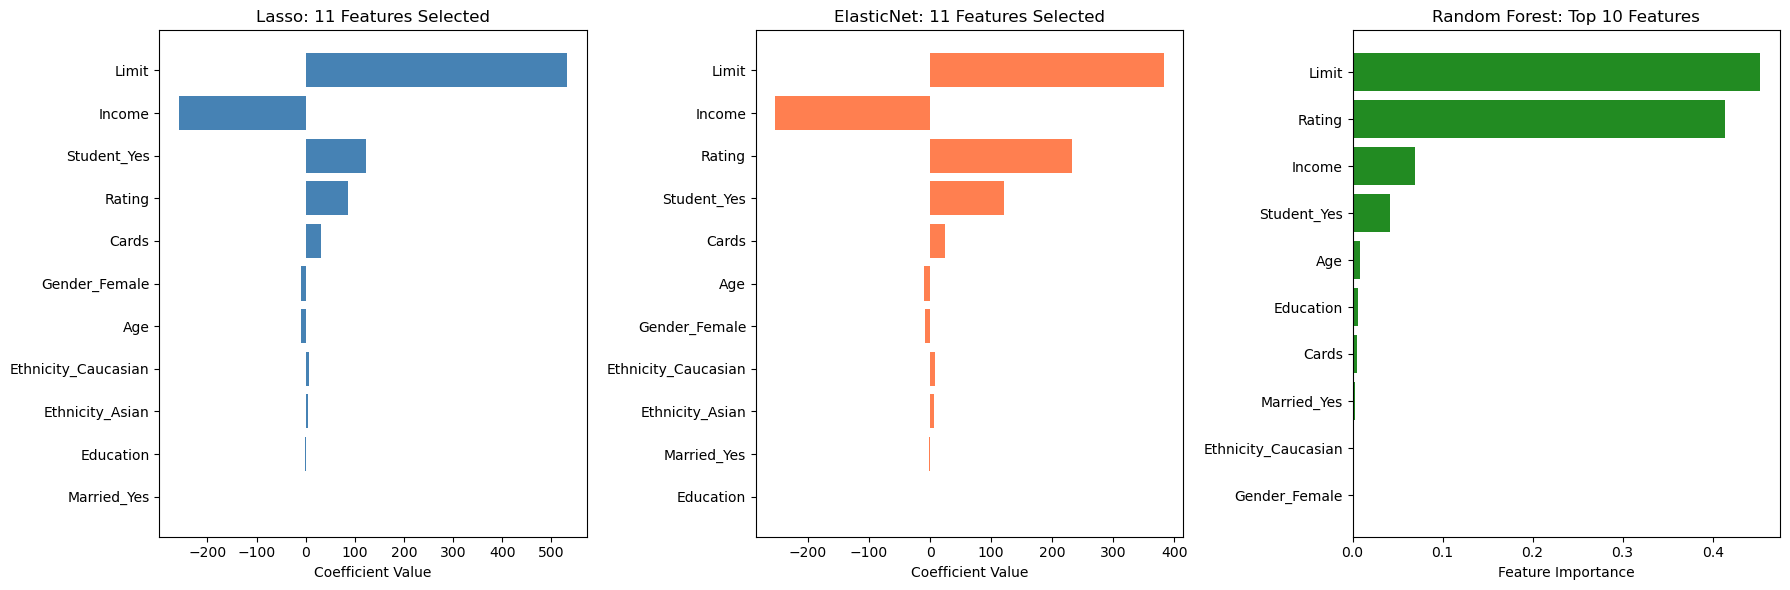

In [11]:

from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor

# Load data
df = pd.read_csv('./Datasets/Credit.csv', index_col=0)

# Separate features and target
X = df.drop(columns=['Balance'])
y = df['Balance']

# Convert categorical variables to dummy variables
X_encoded = pd.get_dummies(X, columns=['Gender', 'Student', 'Married', 'Ethnicity'], drop_first=True)

# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42)

# Standardize features for regularization methods
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Lasso Regression for feature selection
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)

# Get non-zero Lasso coefficients
lasso_coef = pd.Series(lasso.coef_, index=X_encoded.columns)
selected_lasso = lasso_coef[lasso_coef != 0].sort_values(ascending=False, key=abs)

# 2. ElasticNet for feature selection
elasticnet = ElasticNetCV(cv=5, random_state=42, l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99])
elasticnet.fit(X_train_scaled, y_train)

# Get non-zero ElasticNet coefficients
elastic_coef = pd.Series(elasticnet.coef_, index=X_encoded.columns)
selected_elastic = elastic_coef[elastic_coef != 0].sort_values(ascending=False, key=abs)

# 3. Random Forest for feature importance
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
rf_importance = pd.Series(rf.feature_importances_, index=X_encoded.columns)
selected_rf = rf_importance.sort_values(ascending=False)

# Display results
print("=" * 70)
print("LASSO REGRESSION - Selected Features (Non-Zero Coefficients):")
print("=" * 70)
print(selected_lasso)
print(f"\nNumber of features selected: {len(selected_lasso)}/{len(X_encoded.columns)}")
print(f"Optimal alpha: {lasso.alpha_:.4f}")

print("\n" + "=" * 70)
print("ELASTICNET - Selected Features (Non-Zero Coefficients):")
print("=" * 70)
print(selected_elastic)
print(f"\nNumber of features selected: {len(selected_elastic)}/{len(X_encoded.columns)}")
print(f"Optimal alpha: {elasticnet.alpha_:.4f}")
print(f"Optimal l1_ratio: {elasticnet.l1_ratio_:.4f}")

print("\n" + "=" * 70)
print("RANDOM FOREST - Top 10 Feature Importances:")
print("=" * 70)
print(selected_rf.head(10))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Lasso
axes[0].barh(range(len(selected_lasso)), selected_lasso.values, color='steelblue')
axes[0].set_yticks(range(len(selected_lasso)))
axes[0].set_yticklabels(selected_lasso.index)
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title(f'Lasso: {len(selected_lasso)} Features Selected')
axes[0].invert_yaxis()

# ElasticNet
axes[1].barh(range(len(selected_elastic)), selected_elastic.values, color='coral')
axes[1].set_yticks(range(len(selected_elastic)))
axes[1].set_yticklabels(selected_elastic.index)
axes[1].set_xlabel('Coefficient Value')
axes[1].set_title(f'ElasticNet: {len(selected_elastic)} Features Selected')
axes[1].invert_yaxis()

# Random Forest - top 10
top_10_rf = selected_rf.head(10)
axes[2].barh(range(len(top_10_rf)), top_10_rf.values, color='forestgreen')
axes[2].set_yticks(range(len(top_10_rf)))
axes[2].set_yticklabels(top_10_rf.index)
axes[2].set_xlabel('Feature Importance')
axes[2].set_title('Random Forest: Top 10 Features')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

**Interpretation:**

**Lasso (L1 Regularization):**

- Lasso automatically performs feature selection by shrinking less important coefficients to exactly zero.
- Features with non-zero coefficients are considered important. The magnitude indicates relative importance.
- Lasso is particularly useful when you suspect many features are irrelevant or when you want a sparse model.
- **Best for:** Situations where you believe only a small subset of features is truly relevant.

**ElasticNet (L1 + L2 Regularization):**

- Combines Lasso (L1) and Ridge (L2) regularization.
- The `l1_ratio` parameter controls the mix: 1.0 = pure Lasso, 0.0 = pure Ridge.
- Often selects more features than Lasso because the L2 component prevents aggressive shrinkage.
- **Best for:** Situations with correlated features where Lasso might arbitrarily select one and drop others.

**Random Forest Feature Importance:**

- Based on how much each feature decreases impurity (variance for regression) across all trees in the forest.
- Can capture non-linear relationships and feature interactions.
- All features get importance scores (none are exactly zero), but low scores indicate less importance.
- **Best for:** Understanding which features contribute most to prediction, including non-linear effects.

**Key Difference:** 

- **Lasso/ElasticNet** provide automatic feature elimination (coefficients = 0) and work best with linear relationships.
- **Random Forest** ranks all features and captures non-linear patterns but requires manual thresholding.
- **ElasticNet** is more stable than Lasso when features are correlated.

**Connection to Regularization:** These methods directly tie to the **regularization** concepts you learned earlier. The alpha parameter controls the strength of regularization, which in turn controls how many features get eliminated (Lasso/ElasticNet) or how much they're penalized (Ridge/Random Forest).

## Computational Cost and Runtime Comparison

Understanding the computational complexity of each method helps you choose the right approach for your dataset size.

Runtime Comparison:
              Method  Runtime (seconds)
Filter (SelectKBest)           0.002002
Filter (Correlation)           0.003009
  Wrapper (RFECV-LR)           0.086009
  Embedded (LassoCV)           0.086807
       Embedded (RF)           0.170235


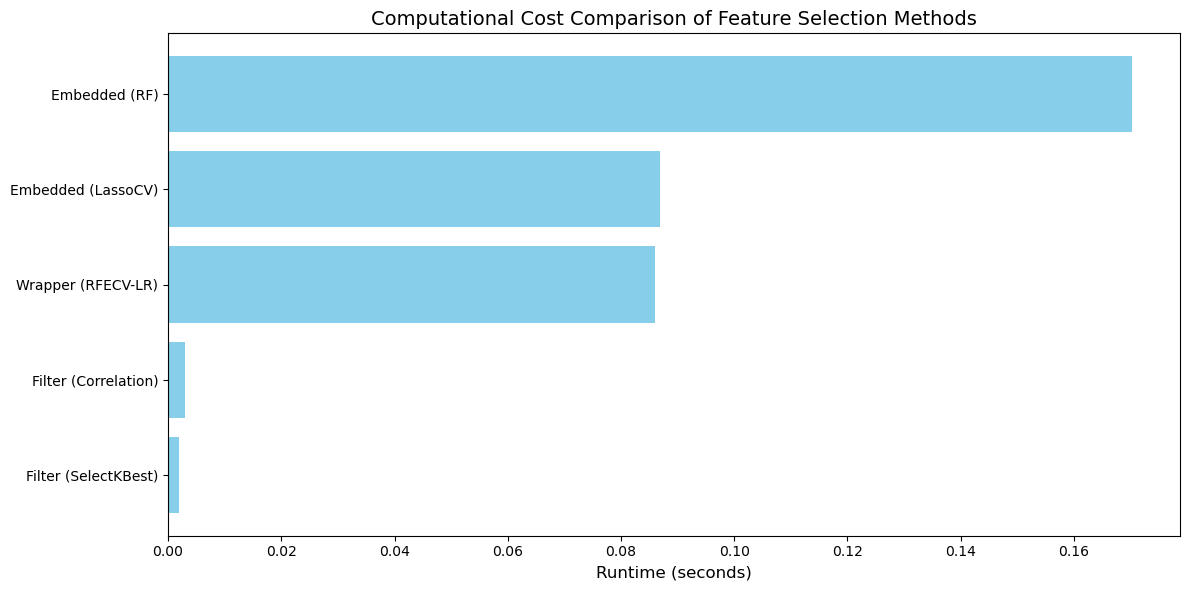


📊 Key Insights:
• Filter methods are fastest (milliseconds) - ideal for large datasets
• Wrapper methods are slowest (seconds to minutes) - best for small datasets where accuracy is critical
• Embedded methods are moderate - Lasso took 0.087s vs RFECV took 0.086s
• For datasets with >1000 features, strongly prefer Filter or Embedded methods


In [12]:
import time

# Prepare data
df = pd.read_csv('./Datasets/Credit.csv', index_col=0)
X = df.drop('Balance', axis=1)
y = df['Balance']
X_encoded = pd.get_dummies(X, columns=['Gender', 'Student', 'Married', 'Ethnicity'])
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Standardize for methods that need it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

runtime_results = {}

# 1. Filter Method: Correlation with Target
start = time.time()
correlations = X_train.apply(lambda col: col.corr(y_train))
selected_features = correlations[abs(correlations) >= 0.2].index
runtime_results['Filter (Correlation)'] = time.time() - start

# 2. Filter Method: SelectKBest
start = time.time()
selector = SelectKBest(score_func=f_regression, k=5)
selector.fit(X_train, y_train)
runtime_results['Filter (SelectKBest)'] = time.time() - start

# 3. Wrapper Method: RFECV with Linear Regression
start = time.time()
rfecv = RFECV(estimator=LinearRegression(), step=1, cv=5, scoring='neg_mean_squared_error')
rfecv.fit(X_train, y_train)
runtime_results['Wrapper (RFECV-LR)'] = time.time() - start

# 4. Embedded Method: Lasso
start = time.time()
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)
runtime_results['Embedded (LassoCV)'] = time.time() - start

# 5. Embedded Method: Random Forest
start = time.time()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
runtime_results['Embedded (RF)'] = time.time() - start

# Create comparison DataFrame
runtime_df = pd.DataFrame({
    'Method': list(runtime_results.keys()),
    'Runtime (seconds)': list(runtime_results.values())
}).sort_values('Runtime (seconds)')

print("Runtime Comparison:")
print(runtime_df.to_string(index=False))

# Visualize
plt.figure(figsize=(12, 6))
plt.barh(runtime_df['Method'], runtime_df['Runtime (seconds)'], color='skyblue')
plt.xlabel('Runtime (seconds)', fontsize=12)
plt.title('Computational Cost Comparison of Feature Selection Methods', fontsize=14)
plt.tight_layout()
plt.show()

print("\n📊 Key Insights:")
print("• Filter methods are fastest (milliseconds) - ideal for large datasets")
print("• Wrapper methods are slowest (seconds to minutes) - best for small datasets where accuracy is critical")
print(f"• Embedded methods are moderate - Lasso took {runtime_results['Embedded (LassoCV)']:.3f}s vs RFECV took {runtime_results['Wrapper (RFECV-LR)']:.3f}s")
print("• For datasets with >1000 features, strongly prefer Filter or Embedded methods")

## Summary: Comparison of Feature Selection Methods

| Method      | Model Dependency | Computational Cost | Handles Feature Interactions | Risk of Overfitting | Best Use Case |
|------------|----------------|-------------------|--------------------------|------------------|--------------|
| **Filter**  | No             | Low               | No                        | Low               | Large datasets, quick exploration |
| **Wrapper** | Yes            | High              | Yes                       | High              | Small datasets, accuracy-critical applications |
| **Embedded** | Yes            | Medium            | Yes (RF/trees)            | Medium            | Balance of speed and accuracy, production models |


### Key Takeaways

**Filter Methods:**

- ✅ Fast and scalable to large datasets
- ✅ Good for initial feature screening
- ❌ Don't consider feature interactions
- ❌ Independent of the final model used

**Wrapper Methods:**

- ✅ Consider feature interactions
- ✅ Optimize for specific model performance
- ❌ Computationally expensive
- ❌ Risk of overfitting to training data

**Embedded Methods:**

- ✅ Balance speed and accuracy
- ✅ Feature selection integrated with model training
- ✅ Less prone to overfitting than wrapper methods
- ✅ Lasso/ElasticNet particularly effective for linear models

### When to Use Each Method

- **Use Filter methods** when:
  - Working with large datasets (>1000 features)
  - Speed is a priority
  - Doing initial exploratory analysis
  - Need to quickly reduce dimensionality before applying more sophisticated methods

- **Use Wrapper methods** when:
  - Working with small to medium datasets (<100 features)
  - Model accuracy is paramount
  - Computational resources and time are available
  - Want to optimize feature set for a specific model

- **Use Embedded methods** when:
  - Need balance between speed and accuracy
  - Building production models (especially with regularization)
  - Using linear models (Lasso/ElasticNet) or tree-based models (Random Forest/XGBoost)
  - Want feature selection that generalizes well

### Connection to Other Concepts

Feature selection relates to several machine learning concepts you've learned:

1. **Regularization (Lasso/Ridge/ElasticNet):** Feature selection is a direct benefit of L1 regularization
2. **Overfitting Prevention:** Removing irrelevant features reduces model complexity and overfitting risk
3. **Cross-Validation:** Many methods (LassoCV, RFECV) use CV to select robust feature subsets
4. **Multicollinearity:** Feature selection can address multicollinearity by removing redundant features
5. **Bias-Variance Trade-off:** Feature selection reduces variance at the potential cost of slight bias increase

By understanding these techniques, you can make better decisions when selecting features for machine learning models and build more efficient, interpretable, and performant models! 

##  Practical Decision Guide: Choosing the Right Feature Selection Method

Use this decision guide to select the most appropriate feature selection method for your specific scenario:

### Decision Flowchart

**START HERE:**

1. **How many features do you have?**
   
   - **< 20 features:** Consider using all features or Wrapper methods (RFECV, Sequential Selection)
   - **20-100 features:** Use Embedded methods (Lasso, ElasticNet, Random Forest) or Filter methods
   - **> 100 features:** Start with Filter methods, then refine with Embedded methods
   - **> 1000 features:** Strongly prefer Filter methods for initial screening

2. **What's more important: Speed or Accuracy?**
   
   - **Speed is critical:** Use Filter methods (Correlation, Variance Threshold, SelectKBest)
   - **Accuracy is critical:** Use Wrapper methods (RFECV, Sequential Selection)
   - **Balance both:** Use Embedded methods (Lasso, ElasticNet, Random Forest)

3. **What type of model are you using?**
   
   - **Linear models (Linear/Logistic Regression):** Lasso, ElasticNet, or Filter methods
   - **Tree-based models (Random Forest, XGBoost):** Built-in feature importance or RFECV
   - **Any model:** RFECV or Sequential Feature Selection (universal)

4. **Do you have multicollinearity (correlated features)?**
   
   - **Yes, highly correlated features:** ElasticNet (handles correlations better) or remove correlated pairs using Filter
   - **No significant correlation:** Lasso or any method

5. **Do you need model interpretability?**
   
   - **Yes, need to explain:** Lasso/ElasticNet (sparse coefficients) or Filter methods
   - **No, just prediction:** Random Forest or any high-performing method

### Quick Reference Table

| Scenario | Recommended Method | Why? |
|----------|-------------------|------|
| Large dataset (>1000 features) | **Filter Methods** | Fast, scales well |
| Small dataset (<100 samples) | **Embedded Methods** | Less prone to overfitting than Wrapper |
| Need fast results | **Correlation Filter, Variance Threshold** | Minimal computation |
| Need best accuracy, time not a concern | **RFECV or Sequential Selection** | Optimizes for specific model |
| Using linear model | **LassoCV or ElasticNetCV** | Built-in regularization + selection |
| Using tree-based model | **Feature Importance from RF/XGBoost** | Native to the algorithm |
| Correlated features | **ElasticNet or Correlation Filter** | Handles multicollinearity |
| Need interpretable results | **Lasso or Filter Methods** | Clear feature rankings/selections |
| Prototyping/exploration | **Filter Methods first, then Embedded** | Quick iteration |
| Production model | **RFECV or ElasticNetCV with CV** | Robust, validated selection |

### Example Workflow

A recommended two-stage approach:

```
Stage 1 (Fast Screening): 
   → Remove low-variance features
   → Remove highly correlated features (keep one from each pair)
   → Select top 50-100 features by correlation with target
   
Stage 2 (Refined Selection):
   → Apply LassoCV or ElasticNetCV (for linear models)
   → OR Apply RFECV (for any model, if time permits)
   → Validate on hold-out test set
```

This approach combines the speed of Filter methods with the accuracy of Embedded/Wrapper methods.

### Reference:
* https://xavierbourretsicotte.github.io/subset_selection.html

* https://www.kaggle.com/code/prashant111/comprehensive-guide-on-feature-selection

* https://www.analyticsvidhya.com/blog/2016/12/introduction-to-feature-selection-methods-with-an-example-or-how-to-select-the-right-variables/

## Independent Study

Now it's your turn! Practice applying different feature selection methods to predict a different target variable.

### Exercise 1: Predict Income Instead of Balance

**Task:** Use the Credit dataset, but this time predict `Income` based on all other features (including `Balance`).

**Instructions:**
1. Prepare the data (encode categorical variables, split train/test)
2. Apply at least THREE different feature selection methods:
   - One Filter method (e.g., correlation with target)
   - One Wrapper method (e.g., RFECV)
   - One Embedded method (e.g., LassoCV or Random Forest)
3. Compare the selected features - do different methods agree?
4. Train a model using each feature subset and compare performance
5. Which method gave the best results? Which was fastest?

### Exercise 2: Feature Selection for Overfitting Prevention

**Task:** Generate a dataset with many irrelevant features and show how feature selection prevents overfitting.

**Instructions:**
```python
# Generate data with many noise features
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=200, n_features=100, 
                      n_informative=10,  # Only 10 useful features!
                      noise=20, random_state=42)
```

1. Split into train/test sets
2. Train a model using ALL 100 features - observe train vs test performance
3. Apply feature selection to identify the ~10 informative features
4. Train a model using only selected features - compare train vs test performance
5. Did feature selection help reduce overfitting?

### Try it yourself!

In [ ]:
# Exercise 1: Your code here
# Predict Income using different feature selection methods

# Step 1: Load and prepare data


# Step 2: Apply Filter Method


# Step 3: Apply Wrapper Method


# Step 4: Apply Embedded Method


# Step 5: Compare results


In [ ]:
# Exercise 2: Your code here
# Show how feature selection prevents overfitting

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Generate data with many noise features


# Step 2: Train model with ALL features


# Step 3: Apply feature selection


# Step 4: Train model with selected features only


# Step 5: Compare performance - did feature selection help?
